# Data Exploration: Heart Disease Dataset

## 1. Load Libraries and Dataset

### Import Necessary Libraries

In [151]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### Load the Dataset

In [152]:
columns = [
    "age", "sex", "cp", "trestbps",
    "chol", "fbs", "restecg",
    "thalach", "exang",
    "oldpeak", "slope",
    "ca", "thal", "target"
]

features = pd.read_csv(
    "../data/01_raw/processed.cleveland.data",
    sep=",",          # dataset separator
    header=None,      # indicates that there are NO headers
    names=columns,     # asigns column names
    na_values = "?"
)

features

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,1
299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,2
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,3
301,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0,1


We can see that the missing values are marked with a question mark, so we will remove them. We also need to convert the float variables back to their original data type of integer.

In [153]:
for col in features.select_dtypes(include='float64').columns:
    if col != 'target':
        if (features[col].dropna() % 1 == 0).all():
            features[col] = features[col].astype('Int64')

In [154]:
features

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,3,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2,7,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,1,110,264,0,0,132,0,1.2,2,0,7,1
299,68,1,4,144,193,1,0,141,0,3.4,2,2,7,2
300,57,1,4,130,131,0,0,115,1,1.2,2,1,7,3
301,57,0,2,130,236,0,2,174,0,0.0,2,1,3,1


In [132]:
# features = features.replace('?', np.nan)

## 2. Data Overview

### Basic Information

In [155]:
features.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    Int64  
 1   sex       303 non-null    Int64  
 2   cp        303 non-null    Int64  
 3   trestbps  303 non-null    Int64  
 4   chol      303 non-null    Int64  
 5   fbs       303 non-null    Int64  
 6   restecg   303 non-null    Int64  
 7   thalach   303 non-null    Int64  
 8   exang     303 non-null    Int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    Int64  
 11  ca        299 non-null    Int64  
 12  thal      301 non-null    Int64  
 13  target    303 non-null    int64  
dtypes: Int64(12), float64(1), int64(1)
memory usage: 36.8 KB


### Check for Missing Values

In [156]:
features.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

The number of missing values observed is relatively small compared to the total size of the dataset: four in 'Major Vessels' and two in 'Thal'. In order to avoid losing information, it was decided not to remove any rows. 

Instead, imputation was performed using the median of each variable. This strategy is well-suited to medical data as it is robust to outliers and preserves the data distribution more effectively than the mean.

In [157]:
features = features.fillna(features.median())
features

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,3,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2,7,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,1,110,264,0,0,132,0,1.2,2,0,7,1
299,68,1,4,144,193,1,0,141,0,3.4,2,2,7,2
300,57,1,4,130,131,0,0,115,1,1.2,2,1,7,3
301,57,0,2,130,236,0,2,174,0,0.0,2,1,3,1


### Dataset Shape

In [158]:
print(features.shape) # dataframe dimension

(303, 14)


Each row in the dataset represents a single patient sample, characterized by multiple features across the table's columns.

The dataset contains 303 patient samples, each defined by 14 features.

## 3. Class Distribution

### Check Unique Classes

We have four types of diagnosis in the dataset:

In [159]:
print(features['target'].unique())

[0 2 1 3 4]


### Count Per Class

Now, let's see how many samples we have for each type of diagnosis.

In [160]:
print(features.groupby('target').size())

target
0    164
1     55
2     36
3     35
4     13
dtype: int64


This dataframe is rather unbalanced, as we see many samples of patients with no disease (target = 0) and significantly fewer samples for the other groups, especially in group 4.

### Class Distribution Visualization

Bar plot and Box plot for each numeric variable will give us a clearer idea of the **distribution** of the input variables:

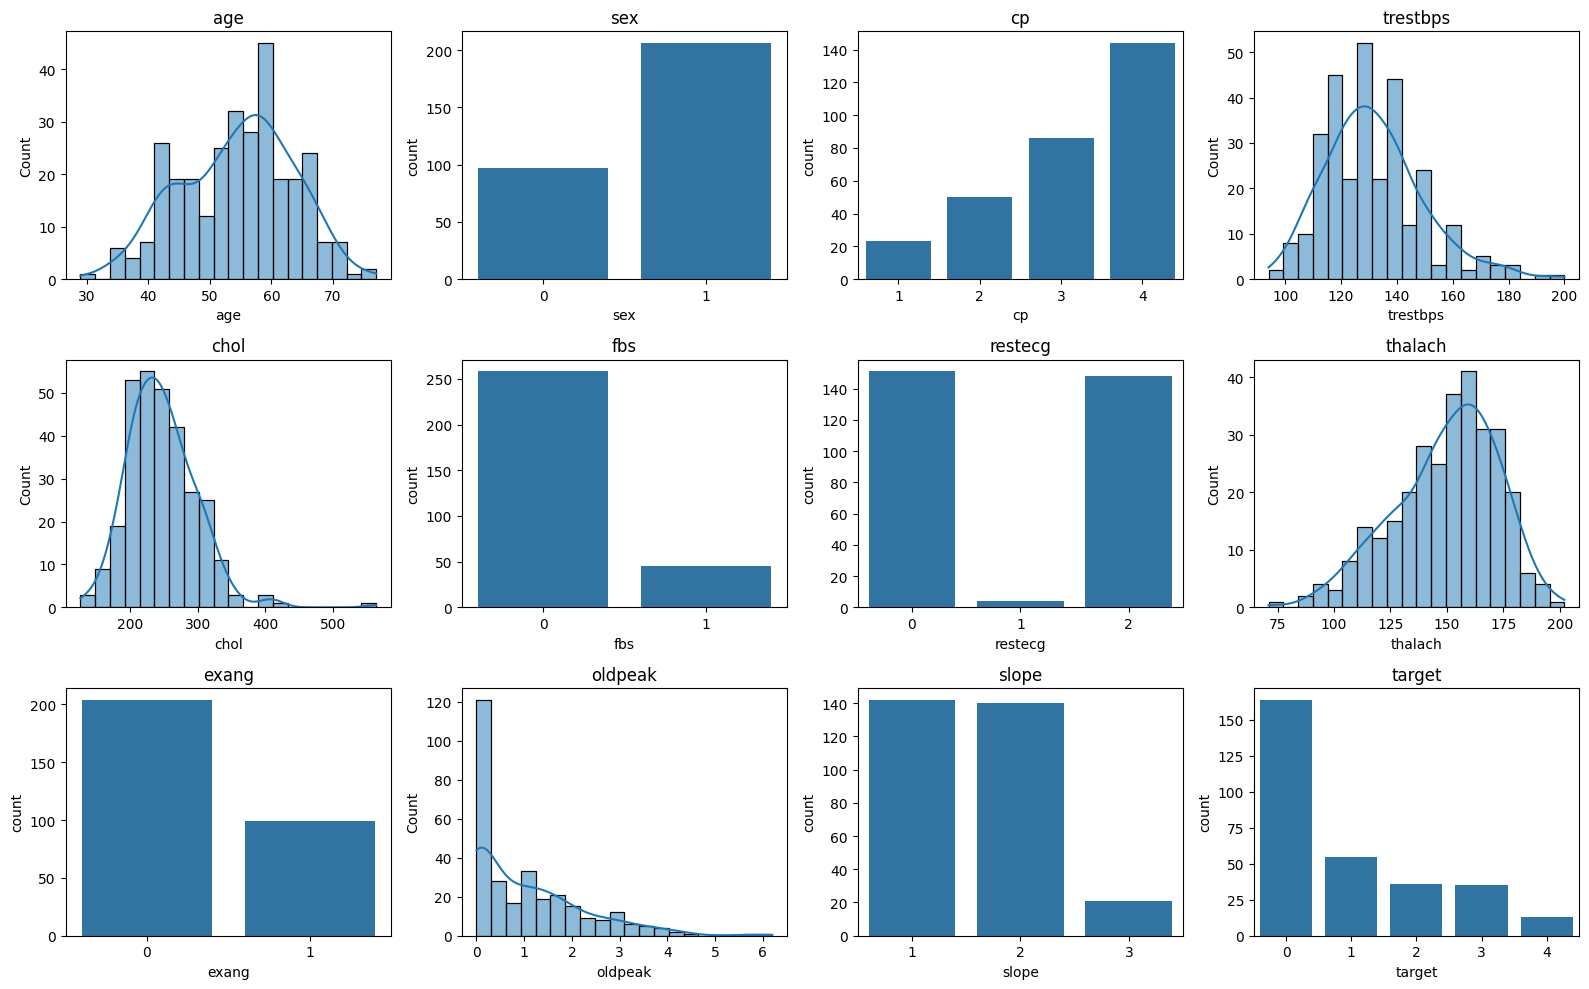

In [161]:
# cols = features.columns

cols = ['age','sex','cp','trestbps','chol','fbs','restecg',
        'thalach','exang','oldpeak','slope','target']

fig, axes = plt.subplots(3, 4, figsize=(16,10))
axes = axes.flatten()

for i, col in enumerate(cols):
    
    if features[col].nunique() < 10:  
        sns.countplot(x=features[col], ax=axes[i])
    else:  
        sns.histplot(features[col], bins=20, kde=True, ax=axes[i])

    axes[i].set_title(col)

plt.tight_layout()
plt.show()


To analyse the distribution of the input variables, two types of visualisation were created, depending on the type of variable. Histograms with a density curve were used for continuous variables, as this type of graph allows one to observe the shape of the distribution, the dispersion of the data and the possible presence of outliers. For categorical or binary variables, on the other hand, frequency bar charts (countplots) were used to show the number of observations in each category and facilitate the identification of potential imbalances in the data.

These visualisations demonstrate that the continuous variables predominantly exhibit unimodal distributions. The age distribution is concentrated mainly between 45 and 65 years, indicating that most patients are middle-aged or older. Resting blood pressure (trestbps) and serum cholesterol (chol) exhibit slightly right-skewed distributions, with some elevated values that could be considered outliers. The maximum heart rate reached (thalach) shows a normal distribution centred around 150 beats per minute, whereas the oldpeak variable exhibits a clearly right-skewed distribution with many values close to zero and few high values.

Bar charts allow us to observe the frequency of each category of a categorical variable. The 'Sex' variable shows that there are more male patients than female patients. For chest pain type (CP), category 4 is the most frequent, followed by categories 3 and 2, while category 1 appears less frequently. The binary variables fbs (fasting blood sugar) and exang (exercise-induced angina) show a clear predominance of category 0, indicating that most patients do not have these conditions. Similarly, categories 0 and 2 predominate in the restecg variable, while category 1 is rare. Finally, the Slope variable is primarily distributed across categories 1 and 2. Taken together, these visualisations provide an initial understanding of the dataset's structure and allow relevant characteristics of the variables that may influence subsequent analysis to be identified.

## 4. Statistical Summary

### Basic Statistics

In [162]:
features.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.0,303.0,303.0,303.0,303.0,303.0,303.0,303.0,303.0,303.000000,303.0,303.0,303.0,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.60066,0.663366,4.722772,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.934375,1.938383,1.228536
min,29.0,0.0,1.0,94.0,126.0,0.0,0.0,71.0,0.0,0.000000,1.0,0.0,3.0,0.000000
25%,48.0,0.0,3.0,120.0,211.0,0.0,0.0,133.5,0.0,0.000000,1.0,0.0,3.0,0.000000
50%,56.0,1.0,3.0,130.0,241.0,0.0,1.0,153.0,0.0,0.800000,2.0,0.0,3.0,0.000000
75%,61.0,1.0,4.0,140.0,275.0,0.0,2.0,166.0,1.0,1.600000,2.0,1.0,7.0,2.000000
max,77.0,1.0,4.0,200.0,564.0,1.0,2.0,202.0,1.0,6.200000,3.0,3.0,7.0,4.000000


The table provides a basic statistical summary of the numerical variables in the dataset. Descriptive statistics are shown for each variable to help you understand the distribution and main characteristics of the data.

Count: This indicates the number of observations available for each variable. In this case, there are 303 observations for all variables, meaning there are no missing data.

Mean: Shows the average of the values. For example, the average age is approximately 54.4 years and the average resting blood pressure is about 132 mmHg.

Std (standard deviation): This indicates the dispersion or variability of the data relative to the mean. Variables such as serum cholesterol (chol) and maximum heart rate achieved (thalach) exhibit significant standard deviations, reflecting variability among patients.

Min and Max indicate the minimum and maximum values observed. For instance, age ranges from 29 to 77 years, while the target variable ranges from 0 to 4, corresponding to different diagnostic categories.

Percentiles (25%, 50%, 75%): These values summarise the distribution by dividing the data into quartiles. The median (50%) age is 56 years, indicating that half of the patients are younger than this age. The other percentiles help to illustrate the concentration of values and any possible asymmetries.

### Mean, Median, and Mode for Age, Resting blood pressure, Serum cholesterol, Max heart rate achieved and ST depression

In [163]:
print("Mean:", features["age"].mean())
print("Median:", features["age"].median())
print("Mode:", features["age"].mode()[0])

Mean: 54.43894389438944
Median: 56.0
Mode: 58


In [164]:
print("Mean:", features["trestbps"].mean())
print("Median:", features["trestbps"].median())
print("Mode:", features["trestbps"].mode()[0])

Mean: 131.68976897689768
Median: 130.0
Mode: 120


In [165]:
print("Mean:", features["chol"].mean())
print("Median:", features["chol"].median())
print("Mode:", features["chol"].mode()[0])

Mean: 246.69306930693068
Median: 241.0
Mode: 197


In [166]:
print("Mean:", features["thalach"].mean())
print("Median:", features["thalach"].median())
print("Mode:", features["thalach"].mode()[0])

Mean: 149.6072607260726
Median: 153.0
Mode: 162


In [167]:
print("Mean:", features["oldpeak"].mean())
print("Median:", features["oldpeak"].median())
print("Mode:", features["oldpeak"].mode()[0])

Mean: 1.0396039603960396
Median: 0.8
Mode: 0.0


## 5. Visualizing Feature Distributions

### Boxplots for Numerical Features

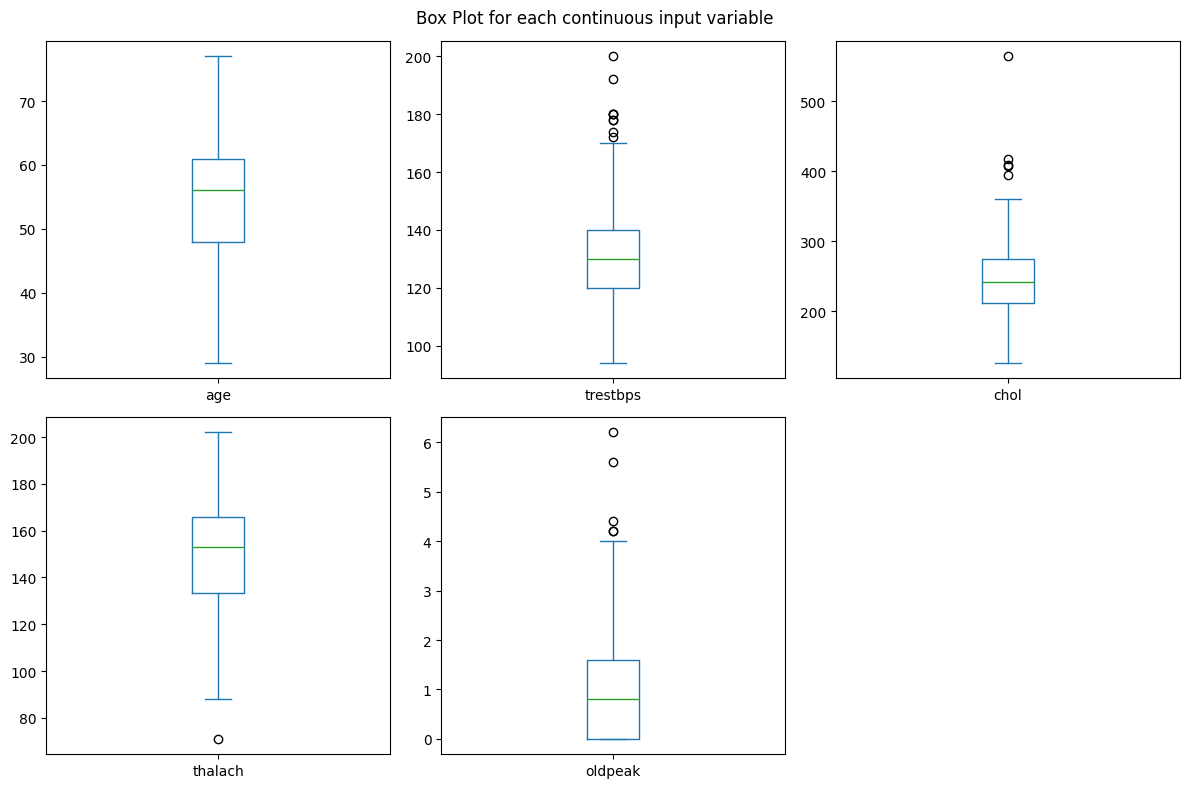

In [168]:
# We select only continuous/ numeric variables
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']  

# We create the character using subplots
features[numeric_cols].plot(
    kind='box',
    subplots=True,
    layout=(2,3),   
    sharex=False,
    sharey=False,
    figsize=(12,8),
    title='Box Plot for each continuous input variable'
)

plt.tight_layout()
plt.savefig('../Figures/heart_data_boxplots.png')
plt.show()

Insight:

* Some features show outliers.


## 6. Feature Correlations

Now we can look at the correlation between the variables, for this purpose, we can make a scatter matrix.

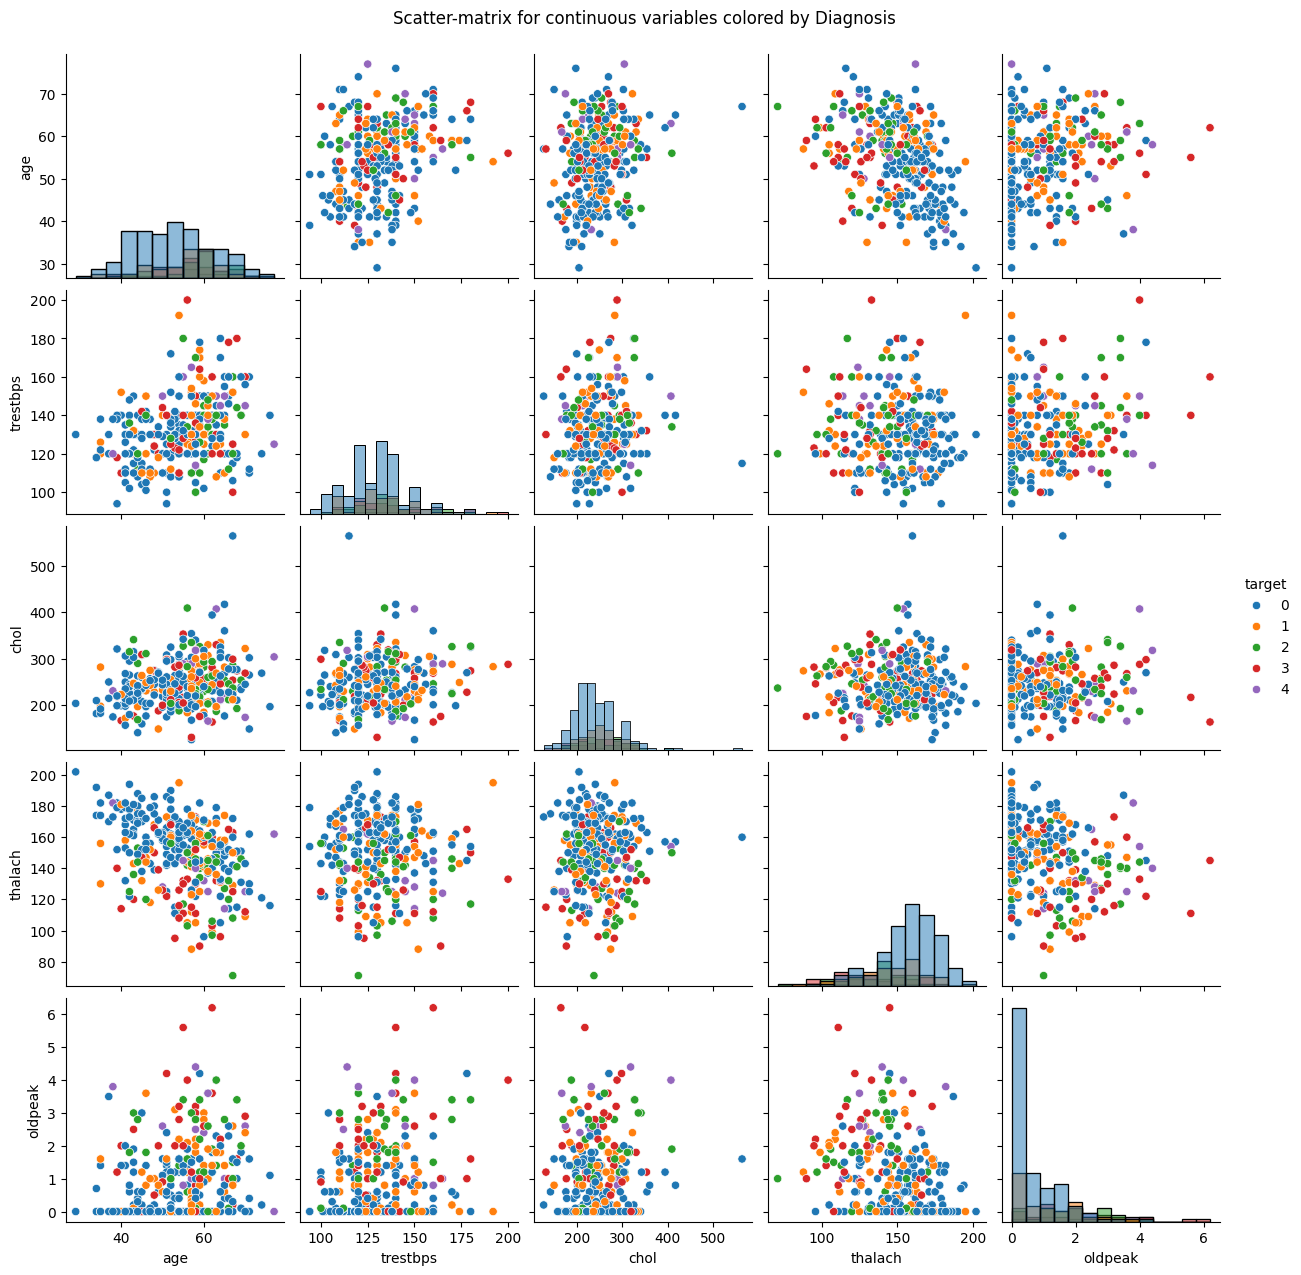

In [169]:
# We select only the continuous variables
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

plot_data = features[continuous_cols + ['target']]

# Pairplot
sns.pairplot(
    plot_data,
    hue='target',           
    diag_kind="hist",       
    palette="tab10"         
)

plt.suptitle('Scatter-matrix for continuous variables colored by Diagnosis', y=1.02)
plt.savefig('../Figures/heart_scatter_matrix.png')
plt.show()

Regarding the relationships between the variables:

* A moderate negative correlation is observed between age and maximum heart rate (as age increases, maximum heart rate decreases).
* No strong linear correlations were identified between most variables, indicating low redundancy.
* There is a relationship between oldpeak and thalach, whereby high oldpeak values tend to be associated with low thalach values. 

Regarding the target variable, the colours show that there is no clear separation between classes in pairs of individual variables. This suggests that:
* Discrimination between classes depends on the combination of multiple variables.
* The relationships may be non-linear, so more complex models will be necessary to capture these patterns.

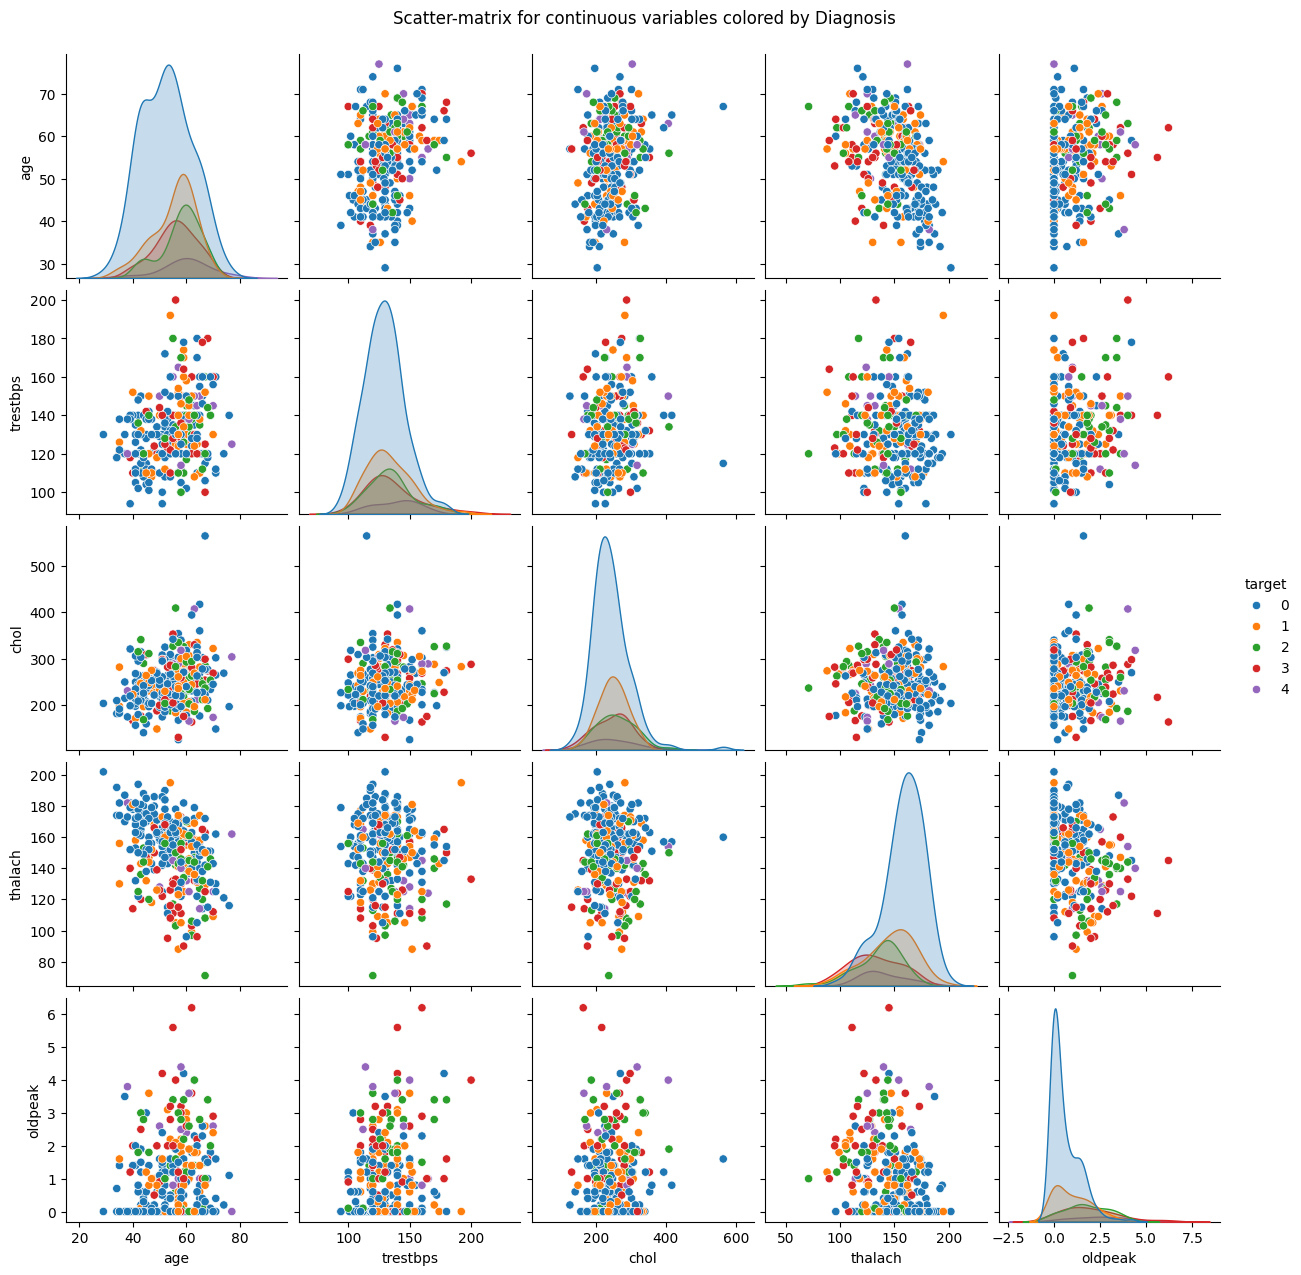

In [170]:
# We select only the continuous variables
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

plot_data = features[continuous_cols + ['target']]

sns.pairplot(
    plot_data,
    hue='target',        
    palette='tab10'      
)

plt.suptitle('Scatter-matrix for continuous variables colored by Diagnosis', y=1.02)
plt.savefig('../Figures/heart_scatter_matrix2.png')
plt.show()

In [178]:
X = features.drop(columns=['target'])  
y = features[['target']]   

features.to_csv('../data/01_raw/raw_dataframe.csv', index=False)
X.to_csv('../data/02_cleaned/cleaned_dataframe.csv', index=False)
y.to_csv('../data/02_cleaned/target_dataframe.csv', index=False)